
# REPA vs SiT-XL/2 Findings from `/workspace/outputs`

This notebook inventories the outputs, reads the main TSV files, groups metrics into
`coarse`, `fine`, and `spatial`, then ranks them with an oriented gain score where
positive means `REPA` is better than `SiT vanilla`.

Main quantitative sources:
- `/workspace/outputs/sit_imagenet_metrics/metrics.tsv`
- `/workspace/outputs/repa_imagenet_metrics/metrics.tsv`
- `/workspace/outputs/sit_imagenet_spatial_metrics/metrics.tsv`
- `/workspace/outputs/repa_imagenet_spatial_metrics/metrics.tsv`

Main visual sources:
- `/workspace/outputs/metrics_compare_plots/*.png`
- `/workspace/outputs/spatial_metrics_compare_plots/*.png`
- `/workspace/outputs/activation_heatmap_compare/sit_vs_repa_activations.png`


In [1]:

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.9)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)

OUTPUTS = Path("/workspace/outputs")
MAIN_FILES = {
    "coarse_sit": OUTPUTS / "sit_imagenet_metrics" / "metrics.tsv",
    "coarse_repa": OUTPUTS / "repa_imagenet_metrics" / "metrics.tsv",
    "spatial_sit": OUTPUTS / "sit_imagenet_spatial_metrics" / "metrics.tsv",
    "spatial_repa": OUTPUTS / "repa_imagenet_spatial_metrics" / "metrics.tsv",
}
GALLERY = [
    OUTPUTS / "metrics_compare_plots" / "repa_vs_sit_metrics_geometry.png",
    OUTPUTS / "metrics_compare_plots" / "repa_vs_sit_metrics_probes.png",
    OUTPUTS / "spatial_metrics_compare_plots" / "repa_vs_sit_spatial_delta_heatmap.png",
    OUTPUTS / "activation_heatmap_compare" / "sit_vs_repa_activations.png",
]

all_output_files = sorted([p for p in OUTPUTS.rglob("*") if p.is_file()])
inventory = pd.DataFrame(
    {
        "path": [str(p) for p in all_output_files],
        "ext": [p.suffix.lower() for p in all_output_files],
        "size_kb": [round(p.stat().st_size / 1024.0, 1) for p in all_output_files],
    }
)
inventory["kind"] = inventory["ext"].map(
    {
        ".tsv": "table",
        ".png": "image",
        ".pdf": "figure",
        ".npy": "array",
        ".npz": "archive",
    }
).fillna("other")


In [2]:

display(Markdown("## 1. Output inventory"))
inventory_summary = (
    inventory.groupby(["kind", "ext"]).size().reset_index(name="count").sort_values(["kind", "ext"])
)
display(inventory_summary)
display(inventory)


## 1. Output inventory

,kind,ext,count
0,archive,.npz,1
1,array,.npy,10
2,figure,.pdf,19
3,image,.png,18
4,other,.ipynb,1
5,table,.tsv,9


,path,ext,size_kb,kind
0,/workspace/outputs/_sanity_geometry_loader_fix/metrics.tsv,.tsv,0.1,table
1,/workspace/outputs/_sanity_geometry_loader_fix/train_subset_indices.npy,.npy,0.6,array
2,/workspace/outputs/_sanity_geometry_loader_fix/val_subset_indices.npy,.npy,0.6,array
3,/workspace/outputs/_sanity_sit_spatial_metrics/metrics.tsv,.tsv,0.2,table
4,/workspace/outputs/_sanity_sit_spatial_metrics/subset_indices.npy,.npy,0.2,array
5,/workspace/outputs/_sanity_sit_spatial_metrics_all_pseudo/metrics.tsv,.tsv,0.5,table
6,/workspace/outputs/_sanity_sit_spatial_metrics_all_pseudo/subset_indices.npy,.npy,0.2,array
7,/workspace/outputs/activation_heatmap_compare/sit_vs_repa_activations.pdf,.pdf,243.1,figure
8,/workspace/outputs/activation_heatmap_compare/sit_vs_repa_activations.png,.png,232.6,image
9,/workspace/outputs/dinov2_pseudo_masks/pseudo_masks.npz,.npz,6009.3,archive


In [3]:

coarse_sit = pd.read_csv(MAIN_FILES["coarse_sit"], sep="\t")
coarse_repa = pd.read_csv(MAIN_FILES["coarse_repa"], sep="\t")
spatial_sit = pd.read_csv(MAIN_FILES["spatial_sit"], sep="\t")
spatial_repa = pd.read_csv(MAIN_FILES["spatial_repa"], sep="\t")

coarse = coarse_repa.merge(
    coarse_sit,
    on=["metric", "layer", "timestep"],
    suffixes=("_repa", "_sit"),
)
spatial = spatial_repa.merge(
    spatial_sit,
    on=["metric", "layer", "noise_level"],
    suffixes=("_repa", "_sit"),
)

higher_better = {
    "linear_top1": True,
    "linear_top5": True,
    "knn_top1": True,
    "knn_recall_at_k": True,
    "cka": True,
    "cknna": True,
    "nc1": False,
    "ncm_acc": True,
    "etf_dev": False,
    "lds": True,
    "cds": True,
    "rmsc": True,
    "lgr": True,
    "msdr": True,
    "graph_gap": True,
    "ubc": True,
    "hf_ratio": True,
    "patch_miou": True,
    "boundary_f1": True,
    "objectness_iou": True,
}

coarse_primary = [
    "linear_top1",
    "linear_top5",
    "knn_top1",
    "knn_recall_at_k",
    "cka",
    "cknna",
    "nc1",
    "ncm_acc",
    "etf_dev",
]
coarse_diagnostic = ["participation_ratio", "effective_rank"]
spatial_primary = ["lds", "cds", "rmsc", "lgr", "msdr", "graph_gap", "ubc", "hf_ratio"]
spatial_diagnostic = ["mad", "entropy", "decay_slope"]
fine_primary = ["patch_miou", "boundary_f1", "objectness_iou"]


def add_gain(df):
    out = df.copy()
    out["value_repa"] = out["value_repa"].astype(float)
    out["value_sit"] = out["value_sit"].astype(float)
    out["delta"] = out["value_repa"] - out["value_sit"]
    out["oriented_gain"] = out.apply(
        lambda r: r["delta"] if higher_better.get(r["metric"], True) else -r["delta"],
        axis=1,
    )
    return out


def summarize_compare(df):
    rows = []
    for metric, sub in df.groupby("metric"):
        rows.append(
            {
                "metric": metric,
                "mean_repa": float(sub["value_repa"].mean()),
                "mean_sit": float(sub["value_sit"].mean()),
                "mean_delta": float(sub["delta"].mean()),
                "mean_abs_delta": float(sub["delta"].abs().mean()),
                "mean_oriented_gain": float(sub["oriented_gain"].mean()),
                "win_rate": float((sub["oriented_gain"] > 0).mean()),
                "best_gain": float(sub["oriented_gain"].max()),
                "worst_gain": float(sub["oriented_gain"].min()),
                "num_points": int(len(sub)),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_oriented_gain", ascending=False)


def layer_band(layer):
    layer = int(layer)
    if layer <= 8:
        return "early"
    if layer <= 18:
        return "mid"
    return "late"


coarse = add_gain(coarse)
spatial = add_gain(spatial)
coarse["layer_band"] = coarse["layer"].map(layer_band)
spatial["layer_band"] = spatial["layer"].map(layer_band)

coarse_summary = summarize_compare(coarse)
spatial_summary = summarize_compare(spatial)
category_tables = {
    "coarse": coarse_summary[coarse_summary["metric"].isin(coarse_primary)].copy(),
    "fine": spatial_summary[spatial_summary["metric"].isin(fine_primary)].copy(),
    "spatial": spatial_summary[spatial_summary["metric"].isin(spatial_primary)].copy(),
    "coarse_diagnostic": coarse_summary[coarse_summary["metric"].isin(coarse_diagnostic)].copy(),
    "spatial_diagnostic_t05": coarse_summary[coarse_summary["metric"].isin(spatial_diagnostic)].copy(),
}


## 2. Visual survey of existing figures

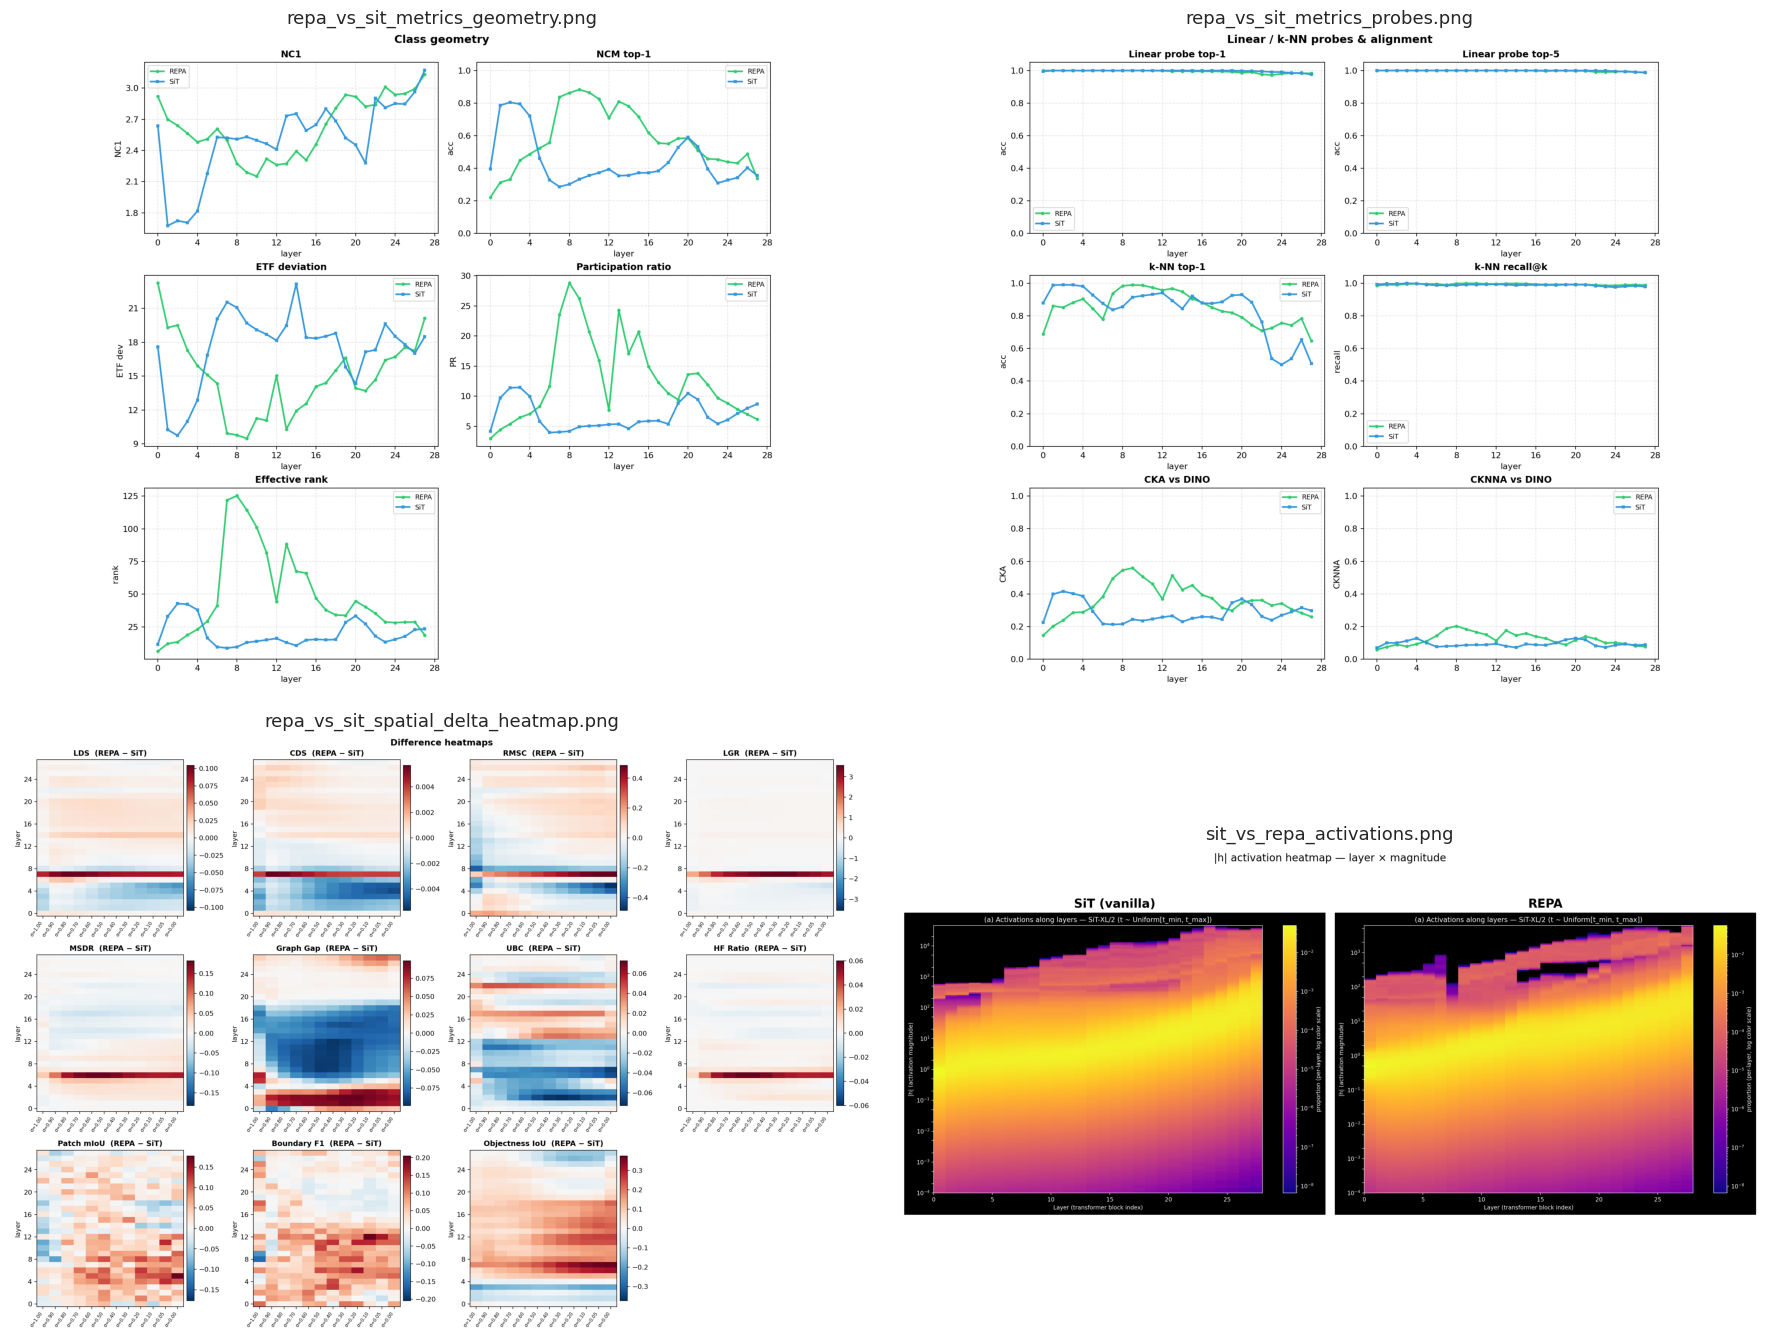

In [4]:

display(Markdown("## 2. Visual survey of existing figures"))
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, path in zip(axes.ravel(), GALLERY):
    img = plt.imread(path)
    ax.imshow(img)
    ax.set_title(path.name, fontsize=13)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:

display(Markdown("## 3. Ranking tables by category"))
for name in ["coarse", "fine", "spatial"]:
    display(Markdown(f"### {name.capitalize()}"))
    table = category_tables[name][
        ["metric", "mean_oriented_gain", "win_rate", "mean_delta", "num_points"]
    ].copy()
    table["mean_oriented_gain"] = table["mean_oriented_gain"].round(4)
    table["win_rate"] = table["win_rate"].round(4)
    table["mean_delta"] = table["mean_delta"].round(4)
    display(table)

display(Markdown("### Coarse diagnostics"))
coarse_diag = category_tables["coarse_diagnostic"][
    ["metric", "mean_delta", "win_rate", "mean_abs_delta"]
].copy()
coarse_diag["mean_delta"] = coarse_diag["mean_delta"].round(4)
coarse_diag["win_rate"] = coarse_diag["win_rate"].round(4)
coarse_diag["mean_abs_delta"] = coarse_diag["mean_abs_delta"].round(4)
display(coarse_diag)

display(Markdown("### Spatial diagnostics at timestep 0.5"))
spatial_diag = category_tables["spatial_diagnostic_t05"][["metric", "mean_delta", "mean_abs_delta"]].copy()
spatial_diag["mean_delta"] = spatial_diag["mean_delta"].round(4)
spatial_diag["mean_abs_delta"] = spatial_diag["mean_abs_delta"].round(4)
display(spatial_diag)


## 3. Ranking tables by category

### Coarse

,metric,mean_oriented_gain,win_rate,mean_delta,num_points
5,etf_dev,2.5806,0.7143,-2.5806,28
13,ncm_acc,0.1355,0.7143,0.1355,28
0,cka,0.0780,0.6786,0.0780,28
1,cknna,0.0297,0.6786,0.0297,28
8,knn_top1,0.0061,0.5000,0.0061,28
7,knn_recall_at_k,0.0038,0.7500,0.0038,28
10,linear_top5,-0.0010,0.0357,-0.0010,28
9,linear_top1,-0.0035,0.1071,-0.0035,28
12,nc1,-0.1193,0.4643,0.1193,28


### Fine

,metric,mean_oriented_gain,win_rate,mean_delta,num_points
7,objectness_iou,0.0639,0.7202,0.0639,336
0,boundary_f1,0.0378,0.7619,0.0378,336
8,patch_miou,0.0239,0.7470,0.0239,336


...

,metric,mean_oriented_gain,win_rate,mean_delta,num_points
5,lgr,0.1100,0.6548,0.1100,336
9,rmsc,0.0067,0.6161,0.0067,336
6,msdr,0.0066,0.5179,0.0066,336
4,lds,0.0036,0.6458,0.0036,336
3,hf_ratio,0.0026,0.6280,0.0026,336
1,cds,-0.0003,0.5625,-0.0003,336
10,ubc,-0.0095,0.3810,-0.0095,336
2,graph_gap,-0.0205,0.4405,-0.0205,336


### Coarse diagnostics

,metric,mean_delta,win_rate,mean_abs_delta
3,effective_rank,28.7378,0.7857,35.7919
14,participation_ratio,6.0183,0.7500,7.7277


### Spatial diagnostics at timestep 0.5

,metric,mean_delta,mean_abs_delta
2,decay_slope,0.0002,0.0012
4,entropy,-0.0882,0.4327
11,mad,-0.8190,1.2945


## 4. Ranking bars

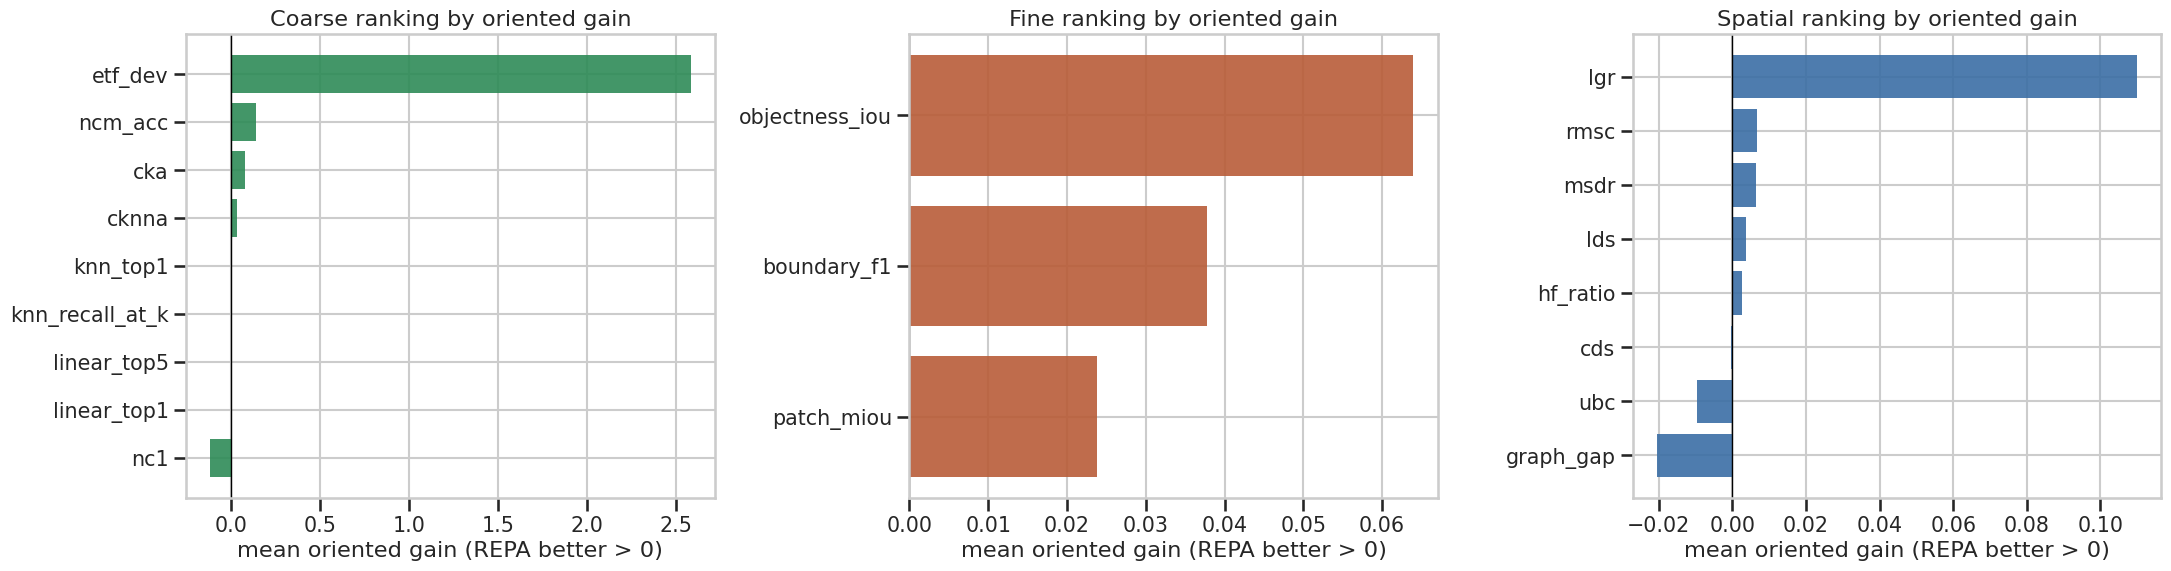

In [6]:

display(Markdown("## 4. Ranking bars"))
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, name, color in zip(
    axes,
    ["coarse", "fine", "spatial"],
    ["#2e8b57", "#b85c38", "#3b6ea5"],
):
    sub = category_tables[name].sort_values("mean_oriented_gain", ascending=True)
    ax.barh(sub["metric"], sub["mean_oriented_gain"], color=color, alpha=0.9)
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set_title(f"{name.capitalize()} ranking by oriented gain")
    ax.set_xlabel("mean oriented gain (REPA better > 0)")
plt.tight_layout()
plt.show()


## 5. Early / Mid / Late layer summary

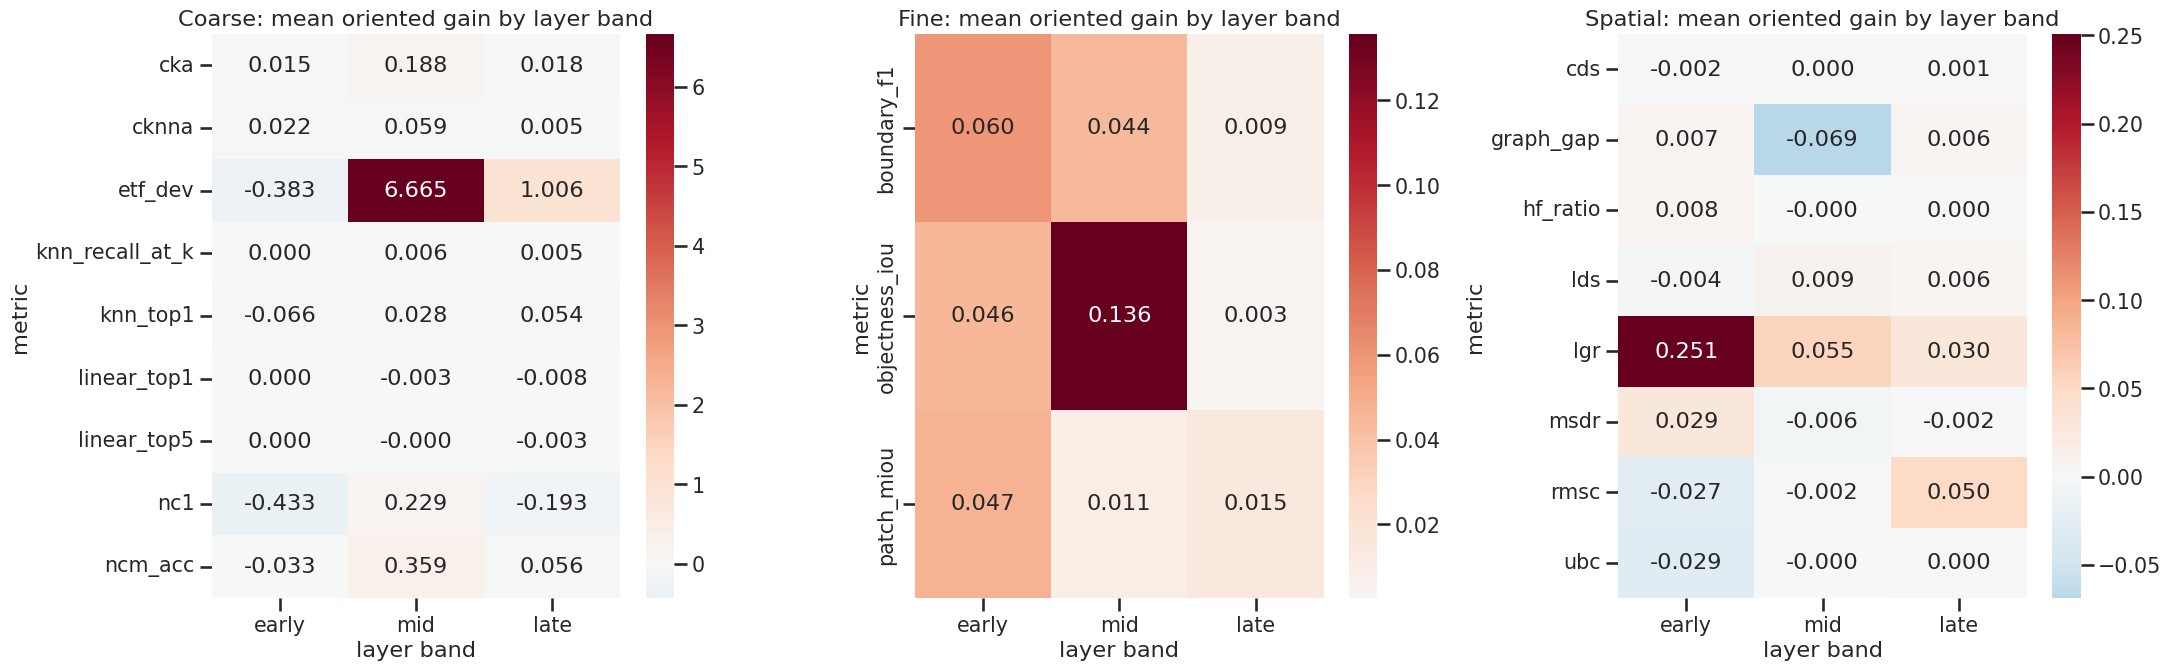

In [7]:

display(Markdown("## 5. Early / Mid / Late layer summary"))
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, title, df, metrics in [
    (axes[0], "Coarse", coarse, coarse_primary),
    (axes[1], "Fine", spatial, fine_primary),
    (axes[2], "Spatial", spatial, spatial_primary),
]:
    pivot = (
        df[df["metric"].isin(metrics)]
        .groupby(["metric", "layer_band"])["oriented_gain"]
        .mean()
        .unstack("layer_band")
    )
    pivot = pivot[["early", "mid", "late"]]
    sns.heatmap(pivot, cmap="RdBu_r", center=0.0, annot=True, fmt=".3f", ax=ax)
    ax.set_title(f"{title}: mean oriented gain by layer band")
    ax.set_xlabel("layer band")
    ax.set_ylabel("metric")
plt.tight_layout()
plt.show()


## 6. Noise profile for fine and spatial metrics

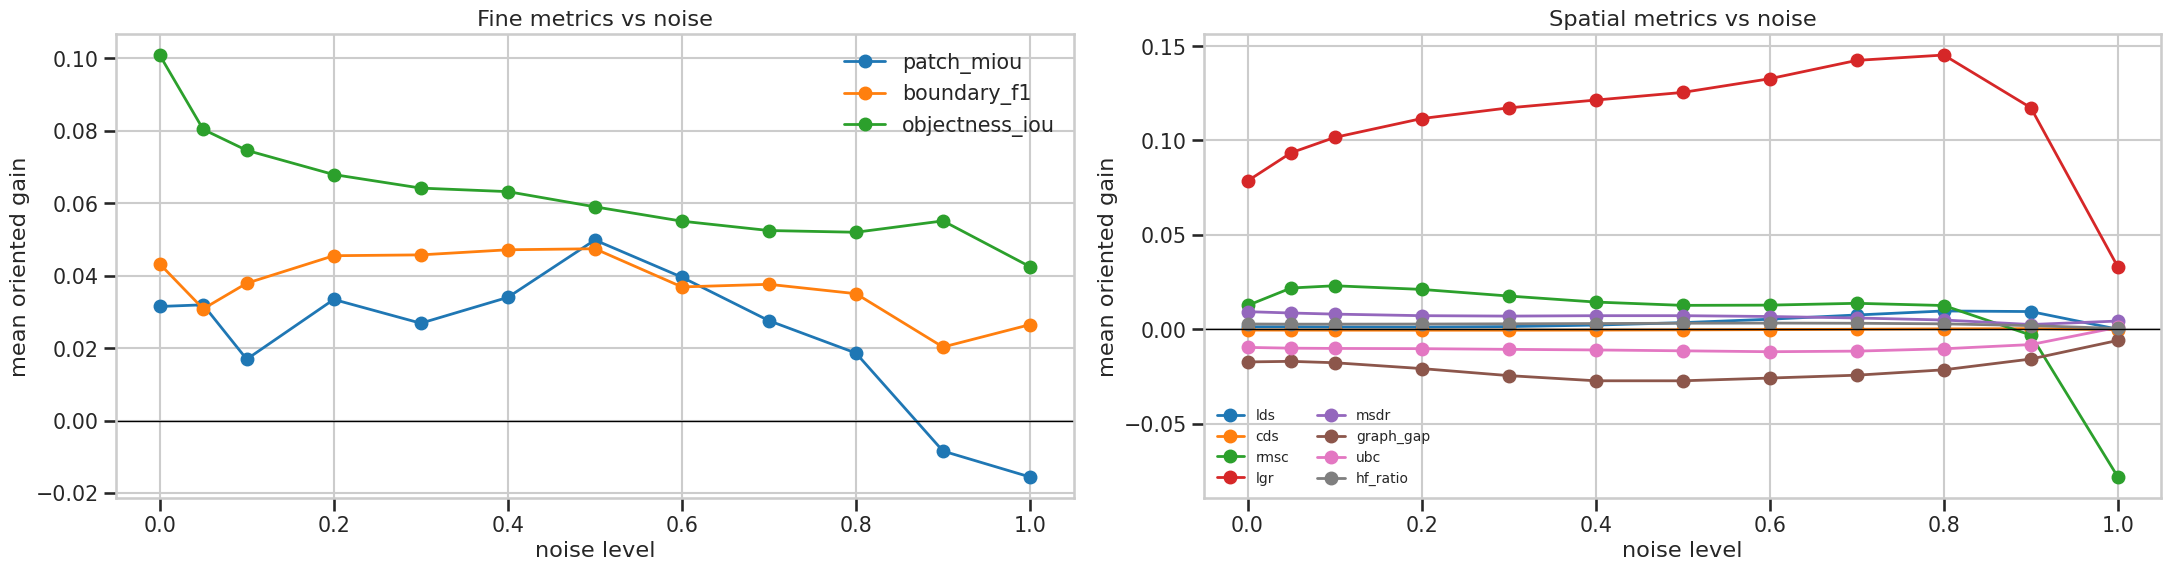

In [8]:

display(Markdown("## 6. Noise profile for fine and spatial metrics"))
fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharex=True)
for metric in fine_primary:
    sub = spatial[spatial["metric"] == metric].groupby("noise_level")["oriented_gain"].mean().reset_index()
    axes[0].plot(sub["noise_level"], sub["oriented_gain"], marker="o", linewidth=2, label=metric)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title("Fine metrics vs noise")
axes[0].set_xlabel("noise level")
axes[0].set_ylabel("mean oriented gain")
axes[0].legend()

for metric in spatial_primary:
    sub = spatial[spatial["metric"] == metric].groupby("noise_level")["oriented_gain"].mean().reset_index()
    axes[1].plot(sub["noise_level"], sub["oriented_gain"], marker="o", linewidth=2, label=metric)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_title("Spatial metrics vs noise")
axes[1].set_xlabel("noise level")
axes[1].set_ylabel("mean oriented gain")
axes[1].legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()


In [9]:

display(Markdown("## 7. Peak gains and hardest failures"))


def peak_rows(df, metrics, extra_col):
    rows = []
    for metric in metrics:
        sub = df[df["metric"] == metric].copy()
        best_idx = sub["oriented_gain"].idxmax()
        worst_idx = sub["oriented_gain"].idxmin()
        best = sub.loc[best_idx]
        worst = sub.loc[worst_idx]
        rows.append(
            {
                "metric": metric,
                f"best_{extra_col}": best[extra_col],
                "best_layer": int(best["layer"]),
                "best_gain": float(best["oriented_gain"]),
                f"worst_{extra_col}": worst[extra_col],
                "worst_layer": int(worst["layer"]),
                "worst_gain": float(worst["oriented_gain"]),
            }
        )
    return pd.DataFrame(rows)


coarse_peaks = peak_rows(coarse, coarse_primary, "timestep")
spatial_peaks = peak_rows(spatial, fine_primary + spatial_primary, "noise_level")

display(Markdown("### Coarse peaks"))
display(coarse_peaks.round(4))

display(Markdown("### Fine + spatial peaks"))
display(spatial_peaks.round(4))


## 7. Peak gains and hardest failures

### Coarse peaks

,metric,best_timestep,best_layer,best_gain,worst_timestep,worst_layer,worst_gain
0,linear_top1,0.5,27,0.0070,0.5,23,-0.0190
1,linear_top5,0.5,25,0.0030,0.5,22,-0.0080
2,knn_top1,0.5,24,0.2560,0.5,0,-0.1910
3,knn_recall_at_k,0.5,8,0.0110,0.5,0,-0.0080
4,cka,0.5,8,0.3306,0.5,1,-0.1965
5,cknna,0.5,8,0.1216,0.5,4,-0.0352
6,nc1,0.5,13,0.4597,0.5,1,-1.0238
7,ncm_acc,0.5,8,0.5609,0.5,1,-0.4734
8,etf_dev,0.5,7,11.5988,0.5,2,-9.7588


### Fine + spatial peaks

,metric,best_noise_level,best_layer,best_gain,worst_noise_level,worst_layer,worst_gain
0,patch_miou,0.0,5,0.1772,0.9,8,-0.0949
1,boundary_f1,0.1,12,0.2044,1.0,8,-0.1585
2,objectness_iou,0.0,7,0.3740,1.0,3,-0.2047
3,lds,0.8,7,0.1043,0.0,5,-0.0607
4,cds,0.9,7,0.0057,0.0,4,-0.0051
5,rmsc,0.0,7,0.4853,0.0,5,-0.4750
6,lgr,0.3,7,3.5473,0.0,5,-0.7448
7,msdr,0.6,6,0.1819,0.6,17,-0.0386
8,graph_gap,0.3,2,0.0990,0.4,12,-0.0963
9,ubc,0.9,22,0.0462,0.3,2,-0.0728


In [10]:

display(Markdown("## 8. Findings"))

coarse_rank = category_tables["coarse"].sort_values("mean_oriented_gain", ascending=False).reset_index(drop=True)
fine_rank = category_tables["fine"].sort_values("mean_oriented_gain", ascending=False).reset_index(drop=True)
spatial_rank = category_tables["spatial"].sort_values("mean_oriented_gain", ascending=False).reset_index(drop=True)

findings_md = f"""
### Executive summary

- **Coarse:** REPA's strongest coarse wins are **{coarse_rank.loc[0, 'metric']}**, **{coarse_rank.loc[1, 'metric']}**, and **{coarse_rank.loc[2, 'metric']}**.
  On this run, coarse gains concentrate most in **mid layers**, especially around `ncm_acc`, `etf_dev`, `cka`, and `cknna`.
- **Fine:** all three fine metrics favor REPA overall. The ranking is **{fine_rank.loc[0, 'metric']} > {fine_rank.loc[1, 'metric']} > {fine_rank.loc[2, 'metric']}**
  by mean oriented gain. Fine wins are strongest in **early-to-mid layers**, with `objectness_iou` standing out most clearly.
- **Spatial:** the strongest spatial win is **{spatial_rank.loc[0, 'metric']}**, followed by **{spatial_rank.loc[1, 'metric']}** and **{spatial_rank.loc[2, 'metric']}**.
  The overall pattern is that REPA improves **local concentration / detail retention**, but not every graph or edge-based metric moves in the same direction.

### Coarse findings

- `ncm_acc` and `etf_dev` clearly favor REPA, while `linear_top1` and `linear_top5` are so saturated that they are weak discriminators here.
- `nc1` does **not** improve uniformly: on average REPA is slightly worse, even though a mid-layer region still favors REPA.
- `participation_ratio` and `effective_rank` are much larger for REPA, which suggests REPA is **less collapsed / more spread out**, not simply more compressed.

### Fine findings

- `objectness_iou` is the clearest fine-grained REPA win.
- `boundary_f1` also improves quite consistently, with a high pointwise win-rate.
- `patch_miou` is positive over most layer/noise settings, but the gain shrinks at very high noise and can occasionally flip sign there.

### Spatial findings

- `lgr` is the strongest spatial signal in favor of REPA and stays positive across most noise levels.
- `msdr`, `lds`, and `hf_ratio` also lean positive for REPA, especially from low to mid noise.
- `graph_gap` and `ubc` are not favorable on average, so the cleanest interpretation is that REPA improves **detail/locality**, but not uniformly **graph partition quality** or **boundary concentration**.

### Layer-wise reading

- REPA's **coarse** wins are strongest in **mid layers**.
- REPA's **fine** wins are strongest in **early-to-mid layers** and then weaken in late layers.
- REPA's **spatial** pattern is mixed: `lgr` is strongest early, while `rmsc` tilts more to late layers.
"""

display(Markdown(findings_md))


## 8. Findings


### Executive summary

- **Coarse:** REPA's strongest coarse wins are **etf_dev**, **ncm_acc**, and **cka**.
  On this run, coarse gains concentrate most in **mid layers**, especially around `ncm_acc`, `etf_dev`, `cka`, and `cknna`.
- **Fine:** all three fine metrics favor REPA overall. The ranking is **objectness_iou > boundary_f1 > patch_miou**
  by mean oriented gain. Fine wins are strongest in **early-to-mid layers**, with `objectness_iou` standing out most clearly.
- **Spatial:** the strongest spatial win is **lgr**, followed by **rmsc** and **msdr**.
  The overall pattern is that REPA improves **local concentration / detail retention**, but not every graph or edge-based metric moves in the same direction.

### Coarse findings

- `ncm_acc` and `etf_dev` clearly favor REPA, while `linear_top1` and `linear_top5` are so saturated that they are weak discriminators here.
- `nc1` does **not** improve uniformly: on average REPA is slightly worse, even though a mid-layer region still favors REPA.
- `participation_ratio` and `effective_rank` are much larger for REPA, which suggests REPA is **less collapsed / more spread out**, not simply more compressed.

### Fine findings

- `objectness_iou` is the clearest fine-grained REPA win.
- `boundary_f1` also improves quite consistently, with a high pointwise win-rate.
- `patch_miou` is positive over most layer/noise settings, but the gain shrinks at very high noise and can occasionally flip sign there.

### Spatial findings

- `lgr` is the strongest spatial signal in favor of REPA and stays positive across most noise levels.
- `msdr`, `lds`, and `hf_ratio` also lean positive for REPA, especially from low to mid noise.
- `graph_gap` and `ubc` are not favorable on average, so the cleanest interpretation is that REPA improves **detail/locality**, but not uniformly **graph partition quality** or **boundary concentration**.

### Layer-wise reading

- REPA's **coarse** wins are strongest in **mid layers**.
- REPA's **fine** wins are strongest in **early-to-mid layers** and then weaken in late layers.
- REPA's **spatial** pattern is mixed: `lgr` is strongest early, while `rmsc` tilts more to late layers.


In [11]:

display(Markdown("## 9. Save compact report tables"))
report_dir = OUTPUTS / "findings_report_assets"
report_dir.mkdir(parents=True, exist_ok=True)
coarse_summary.to_csv(report_dir / "coarse_summary.tsv", sep="\t", index=False)
spatial_summary.to_csv(report_dir / "spatial_summary.tsv", sep="\t", index=False)
category_tables["coarse"].to_csv(report_dir / "coarse_ranking.tsv", sep="\t", index=False)
category_tables["fine"].to_csv(report_dir / "fine_ranking.tsv", sep="\t", index=False)
category_tables["spatial"].to_csv(report_dir / "spatial_ranking.tsv", sep="\t", index=False)
coarse_peaks.to_csv(report_dir / "coarse_peaks.tsv", sep="\t", index=False)
spatial_peaks.to_csv(report_dir / "fine_spatial_peaks.tsv", sep="\t", index=False)
display(Markdown(f"Saved summary TSVs to `{report_dir}`"))


## 9. Save compact report tables

Saved summary TSVs to `/workspace/outputs/findings_report_assets`